### Business Understanding ###
**1. Problem statement**

Kenya’s banking sector faces rising Non-Performing Loans (NPLs) — loans that are not being repaid on time. This reduces bank profitability and threatens financial stability.

The key challenge is:

Can we predict which loans are likely to default so banks can act early?

**2. Why This Matters**


Loan defaults cost banks money.

Predicting defaults early helps banks reduce losses.

Customers can get fairer, data-driven lending decisions.

Strengthens trust and stability in Kenya’s financial system.

**3. Industry and Domain**

Industry: Banking and Financial Services

Domain: Credit Risk Management / Financial Data Science

**4. Target Audience**

Risk managers and credit officers in Kenyan banks

Regulators (e.g., Central Bank of Kenya)

Financial analysts and data scientists

Investors in the banking sector

**5. Impact**

If this predictive system is implemented:

Banks: Reduce non-performing loans and losses.

Customers: Avoid financial distress via proactive support.

Financial ecosystem: Improved trust, stability, and risk management.

Policy makers: Data-driven insights for better regulation.

### Data Understanding

Load libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use("ggplot")

**Load the Dataset**

In [44]:
df = pd.read_csv("loans_full_schema.csv")
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


**inspecting the data**

In [45]:
#getting basic ifno about data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [46]:
# getdescriptive statics about numerical columns
df.describe() 

,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,...,public_record_bankrupt,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees
count,9183.000000,1.000000e+04,9976.000000,1.495000e+03,1495.000000,10000.00000,4342.000000,10000.00000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.930306,7.922215e+04,19.308192,1.279146e+05,19.979304,0.21600,36.760709,2001.29000,1.95820,22.679600,...,0.123800,16361.922500,43.272000,12.427524,476.205323,14458.916610,2494.234773,1894.448466,599.666781,0.119516
std,3.703734,6.473429e+04,15.004851,7.016838e+04,8.054781,0.68366,21.634939,7.79551,2.38013,11.885439,...,0.337172,10301.956759,11.029877,5.001105,294.851627,9964.561865,3958.230365,3884.407175,517.328062,1.813468
min,0.000000,0.000000e+00,0.000000,1.920000e+04,0.320000,0.00000,1.000000,1963.00000,0.00000,2.000000,...,0.000000,1000.000000,36.000000,5.310000,30.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.500000e+04,11.057500,8.683350e+04,14.160000,0.00000,19.000000,1997.00000,0.00000,14.000000,...,0.000000,8000.000000,36.000000,9.430000,256.040000,6679.065000,928.700000,587.100000,221.757500,0.000000
50%,6.000000,6.500000e+04,17.570000,1.130000e+05,19.720000,0.00000,34.000000,2003.00000,1.00000,21.000000,...,0.000000,14500.000000,36.000000,11.980000,398.420000,12379.495000,1563.300000,984.990000,446.140000,0.000000
75%,10.000000,9.500000e+04,25.002500,1.515455e+05,25.500000,0.00000,53.000000,2006.00000,3.00000,29.000000,...,0.000000,24000.000000,60.000000,15.050000,644.690000,20690.182500,2616.005000,1694.555000,825.420000,0.000000
max,10.000000,2.300000e+06,469.090000,1.100000e+06,39.980000,13.00000,118.000000,2015.00000,29.00000,87.000000,...,3.000000,40000.000000,60.000000,30.940000,1566.590000,40000.000000,41630.443684,40000.000000,4216.440000,52.980000


In [47]:
# name of the columns in the dataset
df.columns

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankr

In [48]:
#lets check missing values in the dataset
df.isnull().sum()

emp_title                            833
emp_length                           817
state                                  0
homeownership                          0
annual_income                          0
verified_income                        0
debt_to_income                        24
annual_income_joint                 8505
verification_income_joint           8545
debt_to_income_joint                8505
delinq_2y                              0
months_since_last_delinq            5658
earliest_credit_line                   0
inquiries_last_12m                     0
total_credit_lines                     0
open_credit_lines                      0
total_credit_limit                     0
total_credit_utilized                  0
num_collections_last_12m               0
num_historical_failed_to_pay           0
months_since_90d_late               7715
current_accounts_delinq                0
total_collection_amount_ever           0
current_installment_accounts           0
accounts_opened_

**Lets look at the target variable**

In [49]:
# target variable distribution
df["loan_status"].value_counts(normalize=True)

loan_status
Current               0.9375
Fully Paid            0.0447
In Grace Period       0.0067
Late (31-120 days)    0.0066
Late (16-30 days)     0.0038
Charged Off           0.0007
Name: proportion, dtype: float64

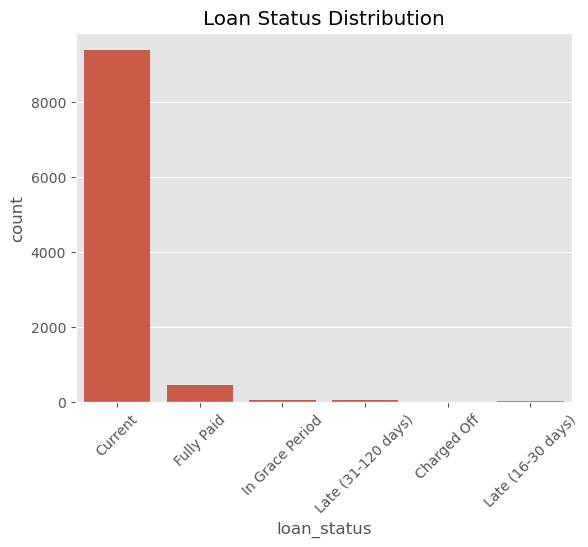

In [50]:
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xticks(rotation=45)
plt.show()

**Check numerical features Distribution**

In [51]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols

Index(['emp_length', 'annual_income', 'debt_to_income', 'annual_income_joint',
       'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt',
       'loan_amount', 'term', 'interest_rate', 'installment', 'balance',
       'paid_total', '

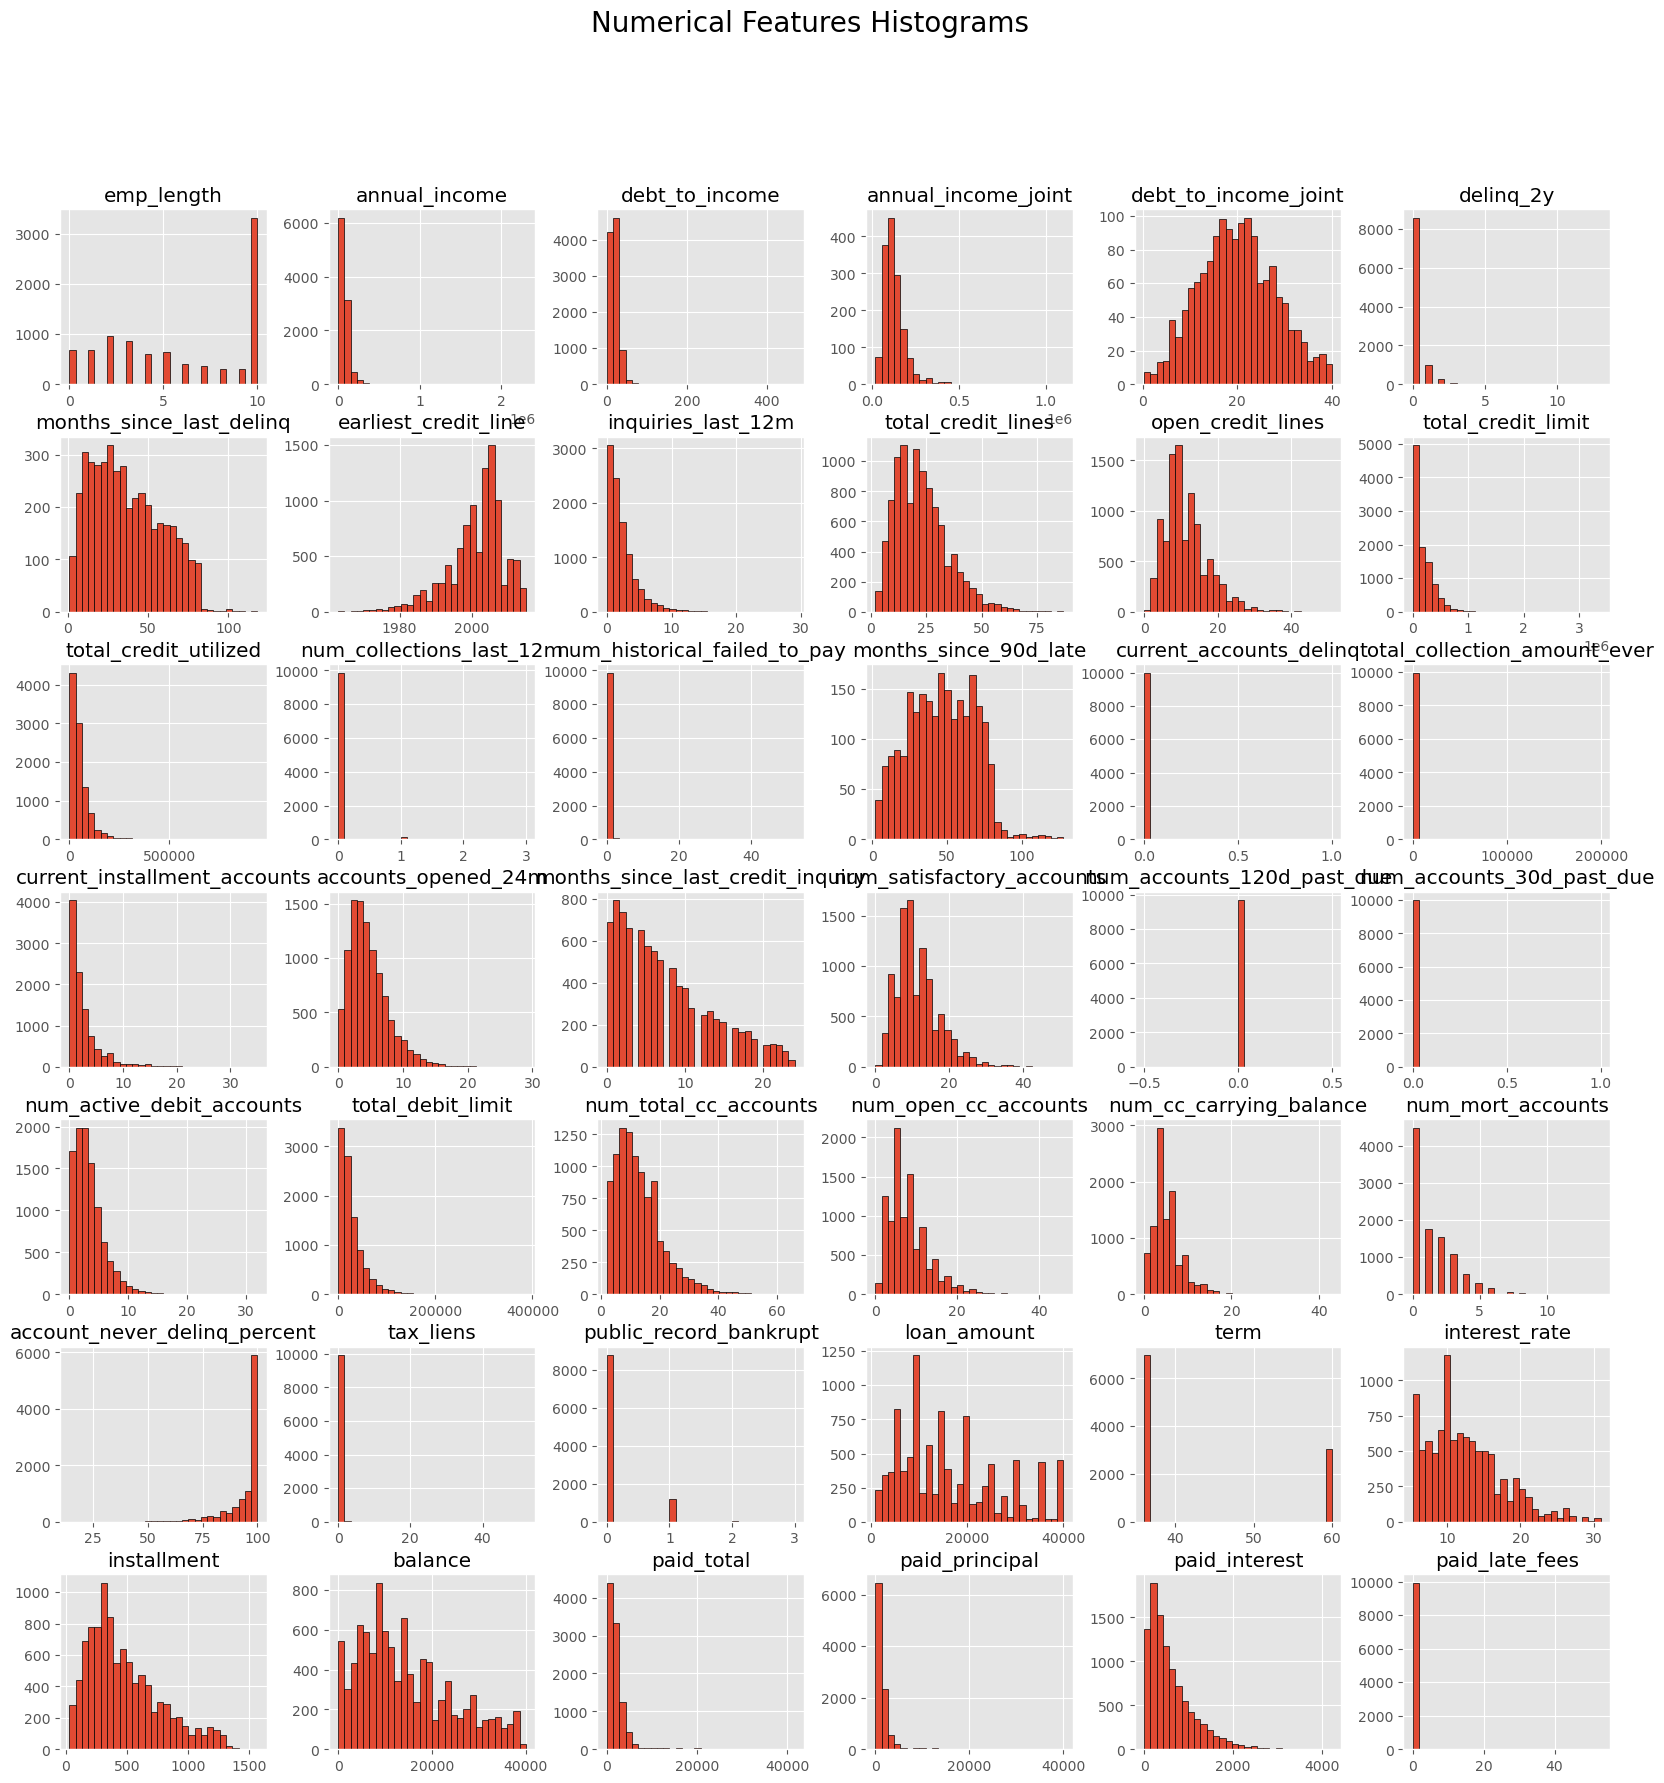

In [52]:
df[num_cols].hist(figsize=(20,20),bins=30,edgecolor='black')
plt.suptitle("Numerical Features Histograms", fontsize=20)
plt.show()

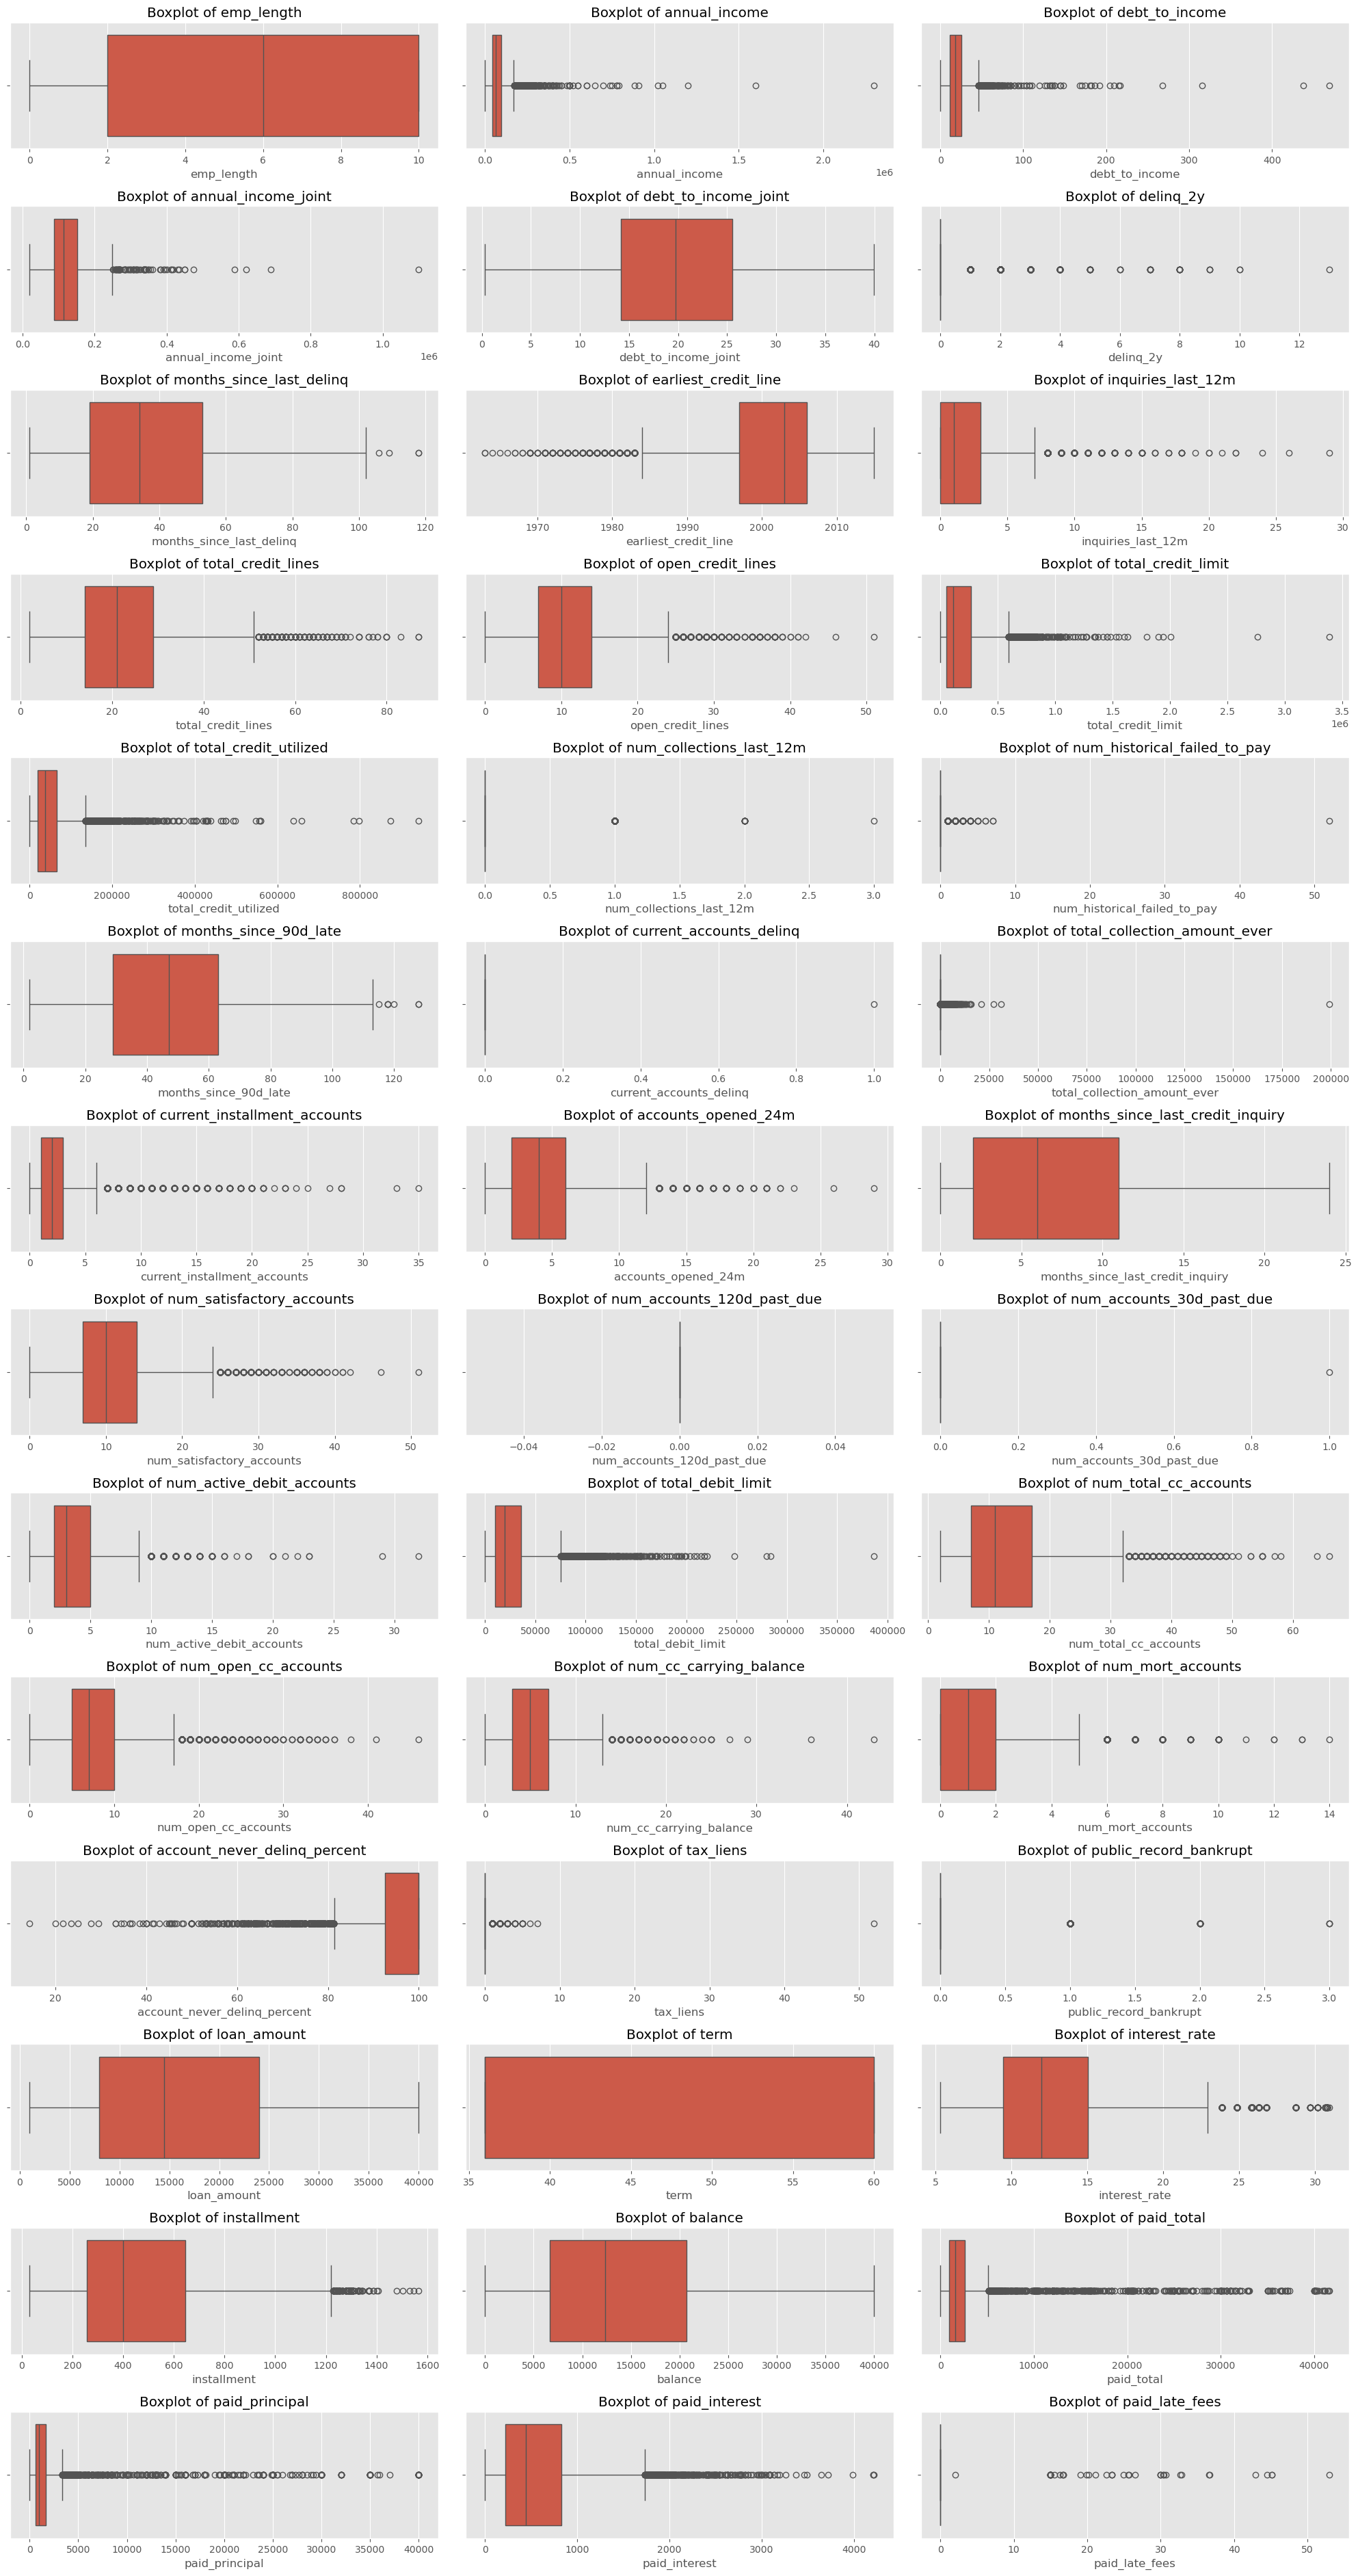

In [53]:
# lets try to detect outliers in the numerical features using boxplots
plt.figure(figsize=(20,40))
for i, col in enumerate(num_cols,1):
    plt.subplot(len(num_cols)//3 +1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [54]:
# lets check for skewness in numerical features
df[num_cols].skew().sort_values(ascending=False)

num_accounts_30d_past_due           100.000000
current_accounts_delinq             100.000000
total_collection_amount_ever         74.581957
tax_liens                            68.213849
num_historical_failed_to_pay         44.035183
paid_late_fees                       17.746922
num_collections_last_12m             10.336184
annual_income                         9.034492
debt_to_income                        8.881588
paid_principal                        6.170454
delinq_2y                             5.874283
paid_total                            5.851660
total_credit_utilized                 4.100792
annual_income_joint                   3.680627
current_installment_accounts          2.850516
total_credit_limit                    2.758754
total_debit_limit                     2.564243
public_record_bankrupt                2.533522
inquiries_last_12m                    2.453752
num_active_debit_accounts             1.665305
paid_interest                         1.643902
num_cc_carryi

**Lets check for Correlations**

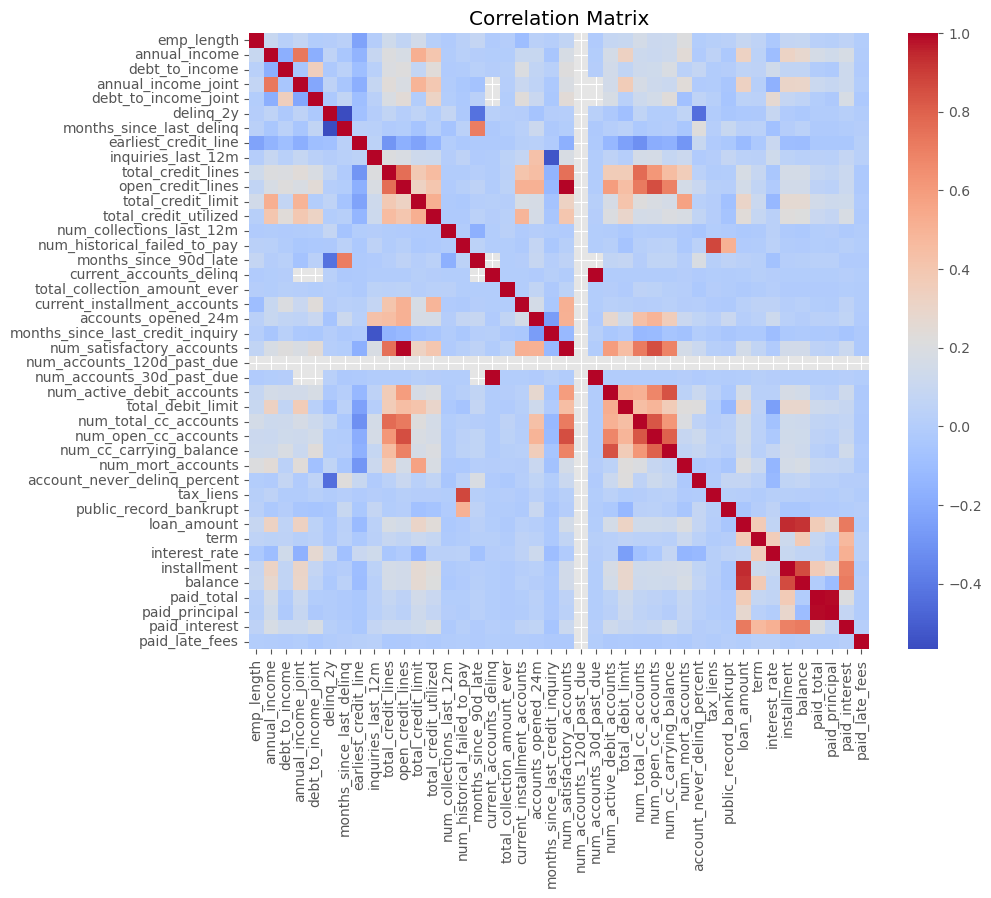

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Data Preparation

In [56]:
# Dropping high missing value columns
cols_to_drop = ['annual_income_joint',
                'verification_income_joint',
                'debt_to_income_joint',
                'months_since_last_delinq',
                'months_since_90d_late']
df.drop(columns=cols_to_drop, inplace=True)

**Impute remaining missing values**

In [57]:
# median imputation for numerical columns
num_cols= df.select_dtypes(include=['int64','float64']).columns
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [58]:
#mode imputation for categorical columns
cat_cols= df.select_dtypes(include=['object']).columns
df[cat_cols]=df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

**Clean and transform columns**
**i.e fixing weird formats/data types**

In [59]:
# emp_length currently float convert to int or bucket
df["emp_length"]= df['emp_length'].astype(int)

In [60]:
# issue_month convert to datetime and extract useful signals
df["issue_month"]= pd.to_datetime(df["issue_month"])
df["issue_year"]= df['issue_month'].dt.year
df['issue_month_num']= df['issue_month'].dt.month
df.drop(columns=["issue_month"], inplace=True)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17688\1321561249.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_month"]= pd.to_datetime(df["issue_month"])


**our target variable is completely imbalanced and predicting default will fail unless we merge classes into meaningful business friendly grouping**

GOOD(0) , current and Fully paid 

BAD(1), all the others

In [61]:
# regrouping the target variable into binary classes
good_status = ['Current', 'Fully Paid']
bad_status =['In Grace Period',
             'Late (16-30 days)',
             'Late (31-120 days)',
             'Default',
             'Charged Off']
df['loan_status_binary']= df['loan_status'].apply(lambda x: 0 if x in good_status else 1)

In [62]:
# Confirming new distribution of target variable
df["loan_status_binary"].value_counts(normalize=True)

loan_status_binary
0    0.9822
1    0.0178
Name: proportion, dtype: float64

In [63]:
df.drop(columns=['loan_status'], inplace=True)

**Fixing skewed numerical features**

we apply log1p transform

In [64]:
skewed_cols = ['num_accounts_30d_past_due',
               'current_accounts_delinq',
               'tax_liens',
               'total_collection_amount_ever',
               'num_historical_failed_to_pay',
               'paid_late_fees']
for col in skewed_cols:
    df[col]=np.log1p(df[col])

**preparing categorical variables for encoding**

In [65]:
# lets drop emp_title as it has too many unique values which creates too many dummy columns
df.drop(columns=["emp_title"], inplace=True)

In [66]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['state', 'homeownership', 'verified_income', 'loan_purpose',
       'application_type', 'grade', 'sub_grade', 'initial_listing_status',
       'disbursement_method'],
      dtype='object')

**Encoding Categorical Variables**

In [67]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

,emp_length,annual_income,debt_to_income,delinq_2y,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,...,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G4,initial_listing_status_whole,disbursement_method_DirectPay
0,3,90000.0,18.01,0,2001,6,28,10,70795,38767,...,False,False,False,False,False,False,False,False,True,False
1,10,40000.0,5.04,0,1996,1,30,14,28800,4321,...,False,False,False,False,False,False,False,False,True,False
2,3,40000.0,21.15,0,2006,4,31,10,24193,16000,...,False,False,False,False,False,False,False,False,False,False
3,1,30000.0,10.16,0,2007,0,4,4,25400,4997,...,False,False,False,False,False,False,False,False,True,False
4,10,35000.0,57.96,0,2008,7,22,16,69839,52722,...,False,False,False,False,False,False,False,False,True,False


In [68]:
df.columns

Index(['emp_length', 'annual_income', 'debt_to_income', 'delinq_2y',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       ...
       'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3',
       'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G4',
       'initial_listing_status_whole', 'disbursement_method_DirectPay'],
      dtype='object', length=145)

**Save cleaned and preprocessed data**

In [69]:
df.to_csv("cleaned_preprocessed_loans_data.csv", index=False)

**Train Test Split**

In [70]:
X = df.drop(columns=['loan_status_binary'])
y = df['loan_status_binary']

**First split Train vs temp**

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, 
                                                    test_size=0.4,  # 40% becomes temp(val+test)
                                                    random_state=42, # class balance kept
                                                    stratify=y)

In [72]:
X_val, X_test, y_val, y_test = train_test_split(X_temp,
                                                y_temp,
                                                test_size = 0.5, # half of temp becomes test that is half of the 20%
                                                random_state=42,
                                                stratify=y_temp)

**Lets do Feature Scaling**

In [73]:
from sklearn.preprocessing import StandardScaler

# Scale only numerical features from the training set
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Lets check the Class Distribution very important**

In [74]:
import pandas as pd

print("Train", y_train.value_counts(normalize=True))
print("Validation", y_val.value_counts(normalize=True))
print("Test", y_test.value_counts(normalize=True))

Train loan_status_binary
0    0.982167
1    0.017833
Name: proportion, dtype: float64
Validation loan_status_binary
0    0.982
1    0.018
Name: proportion, dtype: float64
Test loan_status_binary
0    0.9825
1    0.0175
Name: proportion, dtype: float64
